# Tabelas F1 score da classificação

In [204]:
import pandas as pd

In [205]:
# df = pd.read_csv('results/pu_classify_results_Cora.csv')
# df = pd.read_csv('results/final_pu_classify_results_CiteSeer.csv')
# df = pd.read_csv('results/final_pu_classify_results_PubMed.csv')
# df = pd.read_csv('results/pu_classify_results_Photo.csv')
# df = pd.read_csv('results/pu_classify_results_dblp.csv')

df = pd.read_csv('results/final_gnn_neg_inf_results_PubMed.csv')



In [206]:
df.columns

Index(['Unnamed: 0', 'acc', 'f1', 'precision', 'recall', '1/1', '0/0', '0/1',
       '1/0', 'model', 'dataset', 'rate', 'length negatives',
       'length positives'],
      dtype='object')

In [207]:
import pandas as pd

# Supondo que seu dataframe seja df
# df_grouped = df.groupby(['rate', 'model'])[['acc', 'f1']].mean().reset_index()

df_grouped = df.groupby(['rate', 'model'])['f1'].agg(
    f1='mean',
    f1_std='std'
).reset_index()


In [208]:
model_name = 'RGraphSage'

In [209]:
df_grouped[df_grouped['model'] ==model_name]

,rate,model,f1,f1_std


In [210]:
def format_f1_with_std(df):
    return df.apply(lambda row: f"{round(row['f1'], 4)} ± {round(row['f1_std'], 2)}", axis=1)

In [211]:
latex_df = df_grouped[df_grouped['model'] == model_name][['f1', 'f1_std']]


latex_df['f1_fmt'] = format_f1_with_std(latex_df)

output_str = ''

for value in latex_df['f1_fmt']:
    output_str += value + ' & ' 

output_str = output_str[:-2]
output_str = model_name + '&  ' + output_str + r'\\hline'


output_str

'RGraphSage&  \\\\hline'

In [212]:
df_grouped[df_grouped['rate'] == 0.01]

,rate,model,f1,f1_std
0,0.01,DropEdgeGCN,0.97462,0.007436
1,0.01,GCN,0.98010,0.000000
2,0.01,RGCN,0.96498,0.007641
3,0.01,SkipNodeGCN,0.85462,0.041907


In [213]:
df_grouped[df_grouped['rate'] == 0.05]

,rate,model,f1,f1_std
16,0.05,DropEdgeGCN,0.97856,0.005354
17,0.05,GCN,0.98176,0.004083
18,0.05,RGCN,0.98952,0.002087
19,0.05,SkipNodeGCN,0.91522,0.026071


In [214]:
df_grouped[df_grouped['rate'] == 0.1]

,rate,model,f1,f1_std
36,0.1,DropEdgeGCN,0.97304,0.004468
37,0.1,GCN,0.97226,0.010467
38,0.1,RGCN,0.99400,0.001065
39,0.1,SkipNodeGCN,0.89226,0.020568


In [215]:
df_grouped[df_grouped['rate'] == 0.15]

,rate,model,f1,f1_std
56,0.15,DropEdgeGCN,0.97318,0.010202
57,0.15,GCN,0.96360,0.007148
58,0.15,RGCN,0.99574,0.000918
59,0.15,SkipNodeGCN,0.88356,0.031870


In [216]:
df_grouped[df_grouped['rate'] == 0.2]

,rate,model,f1,f1_std
76,0.2,DropEdgeGCN,0.96470,0.006892
77,0.2,GCN,0.96522,0.002952
78,0.2,RGCN,0.99690,0.000539
79,0.2,SkipNodeGCN,0.90164,0.011988


In [217]:
df_grouped[df_grouped['rate'] == 0.25]

,rate,model,f1,f1_std
96,0.25,DropEdgeGCN,0.96390,0.008794
97,0.25,GCN,0.96574,0.005974
98,0.25,RGCN,0.99726,0.000541
99,0.25,SkipNodeGCN,0.90762,0.017352


# Analysis neg_inf

In [218]:
import pandas as pd
import matplotlib.pyplot as plt

dataset_name = 'Cora'


df_neurais = pd.read_csv(f'results/final_gnn_neg_inf_results_{dataset_name}.csv')
df_concorrentes = pd.read_csv(f'results/neg_inf_results_{dataset_name}.csv')

df = pd.concat([df_neurais, df_concorrentes])

In [219]:
cores_modelos = {
    'RGCN': '#1f77b4',  # Azul
    'GCN': '#ff7f0e',    # Laranja
    'SkipNodeGCN': '#2ca02c',  # Verde
    'DropEdgeGCN': '#d62728',  # Vermelho
    'MCLS': '#9467bd',   # Roxo
    'PU_LP': '#8c564b',   # Marrom
    'LP_PUL': '#e377c2',  # Rosa
    'CCRNE': '#7f7f7f',   # Cinza
    'RCSVM': '#bcbd22',   # Amarelo
}

## Modelos Neurais

In [220]:
modelos_neurais = ['RGCN', 'GCN', 'DropEdgeGCN', 'SkipNodeGCN']
# Filtra o DataFrame apenas com os modelos presentes na lista
df_neurais = df[df['model'].isin(modelos_neurais)].copy()

# Verifique o resultado
print(df_neurais.head())

   Unnamed: 0     acc      f1  precision  recall  1/1   0/0  0/1  1/0  \
0           0  0.8750  0.9333     0.8750     1.0  0.0   7.0  0.0  1.0   
1           1  0.7500  0.8571     0.7500     1.0  0.0   6.0  0.0  2.0   
2           2  1.0000  1.0000     1.0000     1.0  NaN   NaN  NaN  NaN   
3           3  0.8750  0.9333     0.8750     1.0  0.0   7.0  0.0  1.0   
4           4  0.8125  0.8966     0.8125     1.0  0.0  13.0  0.0  3.0   

         model dataset  rate  length negatives  length positives  
0         RGCN    Cora  0.01                 8                 8  
1          GCN    Cora  0.01                 8                 8  
2  SkipNodeGCN    Cora  0.01                 8                 8  
3  DropEdgeGCN    Cora  0.01                 8                 8  
4         RGCN    Cora  0.02                16                16  


[]

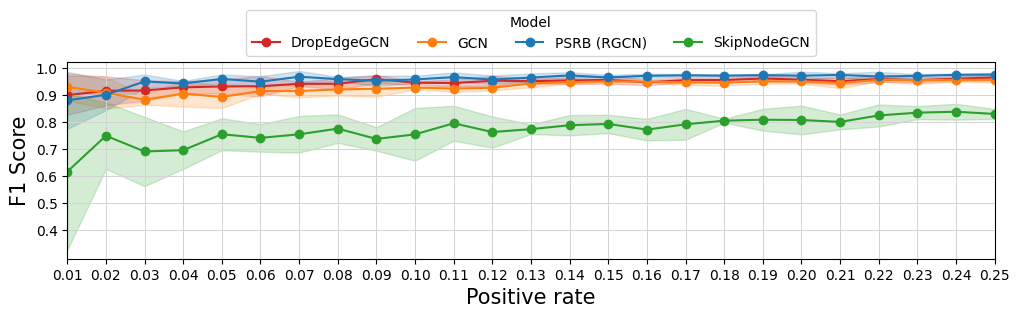

In [221]:
# Agrupar por 'rate' e 'model', e calcular média e desvio padrão
summary = df_neurais.groupby(['rate', 'model'])['f1'].agg(['mean', 'std']).reset_index()

# Lista de modelos únicos
modelos = summary['model'].unique()

# Plot
plt.figure(figsize=(10.3, 3.5))  # largura exata, altura ajustável conforme necessário

for model in modelos:
    dados_modelo = summary[summary['model'] == model]
    rates = dados_modelo['rate']
    medias = dados_modelo['mean']
    desvios = dados_modelo['std']
    
    cor = cores_modelos.get(model, '#000000')

    # Trocar o nome 'RGCN' por 'PSRB (RGCN)' na legenda
    if model == 'RGCN':
        label = 'PSRB (RGCN)'
    else:
        label = model
    
    # Linha principal (média do F1)
    plt.plot(rates, medias, label=label, marker='o', color = cor)
    
    # Faixa do desvio padrão (transparente)
    plt.fill_between(rates, medias - desvios, medias + desvios, alpha=0.2, color = cor)


# Ajustar limites do eixo X para 0.01 a 0.25
plt.xlim(0.01, 0.25)
# plt.ylim(0.4,1.1)

plt.xlabel('Positive rate', fontsize = 15)
plt.ylabel('F1 Score', fontsize = 15)
# plt.title('Desempenho dos modelos com diferentes taxas de dados rotulados')
# plt.legend(title='Model', fontsize = 10)
plt.legend(title='Model', bbox_to_anchor=(0.5, 1.3), loc='upper center', ncol=7)
plt.xticks(ticks=[x/100 for x in range(1,26)],fontsize=10)
plt.yticks(fontsize=10, ticks = [0.4,0.5,0.6,0.7,0.8,0.9,1])
plt.grid(True, color='lightgray', linewidth=0.7, which='both')
plt.tight_layout()
plt.savefig(f'plots/neg_inf_{dataset_name}_neural.svg', format='svg')
plt.plot()

In [222]:
modelos_nao_neurais = ['RGCN', 'CCRNE', 'MCLS', 'LP_PUL', 'PU_LP', 'RCSVM']
# Filtra o DataFrame apenas com os modelos presentes na lista
df_nao_neurais = df[df['model'].isin(modelos_nao_neurais)].copy()

# Verifique o resultado
print(df_nao_neurais.head())

    Unnamed: 0     acc      f1  precision  recall  1/1   0/0  0/1  1/0 model  \
0            0  0.8750  0.9333     0.8750     1.0  0.0   7.0  0.0  1.0  RGCN   
4            4  0.8125  0.8966     0.8125     1.0  0.0  13.0  0.0  3.0  RGCN   
8            8  0.9167  0.9565     0.9167     1.0  0.0  22.0  0.0  2.0  RGCN   
12          12  0.8750  0.9333     0.8750     1.0  0.0  28.0  0.0  4.0  RGCN   
16          16  0.9500  0.9744     0.9500     1.0  0.0  38.0  0.0  2.0  RGCN   

   dataset  rate  length negatives  length positives  
0     Cora  0.01                 8                 8  
4     Cora  0.02                16                16  
8     Cora  0.03                24                24  
12    Cora  0.04                32                32  
16    Cora  0.05                40                40  


[]

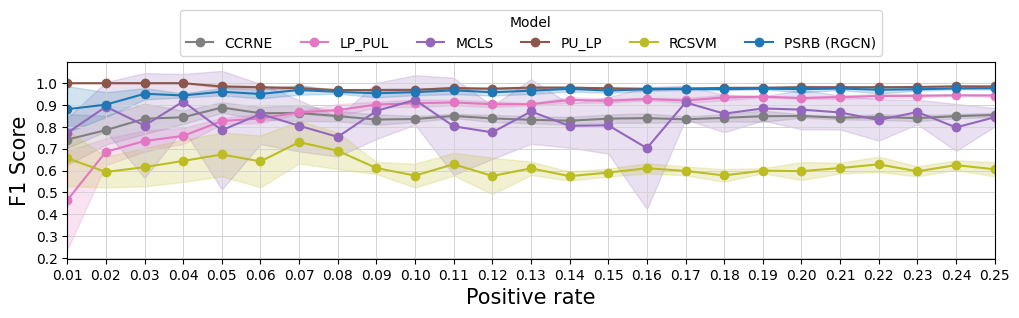

In [223]:
# Agrupar por 'rate' e 'model', e calcular média e desvio padrão
summary = df_nao_neurais.groupby(['rate', 'model'])['f1'].agg(['mean', 'std']).reset_index()

# Lista de modelos únicos
modelos = summary['model'].unique()

# Plot
plt.figure(figsize=(10.3, 3.5))  # largura exata, altura ajustável conforme necessário

for model in modelos:
    dados_modelo = summary[summary['model'] == model]
    rates = dados_modelo['rate']
    medias = dados_modelo['mean']
    desvios = dados_modelo['std']
    
    cor = cores_modelos.get(model, '#000000')

    # Trocar o nome 'RGCN' por 'PSRB (RGCN)' na legenda
    if model == 'RGCN':
        label = 'PSRB (RGCN)'
    else:
        label = model
    
    # Linha principal (média do F1)
    plt.plot(rates, medias, label=label, marker='o', color = cor)
    
    # Faixa do desvio padrão (transparente)
    plt.fill_between(rates, medias - desvios, medias + desvios, alpha=0.2, color = cor)


# Ajustar limites do eixo X para 0.01 a 0.25
plt.xlim(0.01, 0.25)
# plt.ylim(0.4,1.1)

plt.xlabel('Positive rate', fontsize = 15)
plt.ylabel('F1 Score', fontsize = 15)
# plt.title('Desempenho dos modelos com diferentes taxas de dados rotulados')
# Ajustar a posição e formato da legenda
# plt.legend(
#     title='Modelo',
#     fontsize=10,
#     loc='upper center',  # Coloca a legenda na parte superior
#     bbox_to_anchor=(0.5, 1.15),  # Move a legenda um pouco para cima
#     borderpad=1,  # Aumenta a largura da caixa
#     handlelength=2,  # Aumenta o comprimento das linhas da legenda
#     labelspacing=1.2  # Aumenta o espaçamento entre os itens da legenda
# )
plt.legend(title='Model', bbox_to_anchor=(0.5, 1.3), loc='upper center', ncol=7)
plt.xticks(ticks=[x/100 for x in range(1,26)],fontsize=10)
plt.yticks(fontsize=10, ticks = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])
plt.grid(True, color='lightgray', linewidth=0.7, which='both')
plt.tight_layout()
plt.savefig(f'plots/neg_inf_{dataset_name}_nao_neural.svg', format='svg')
plt.plot()

# Análise de épocas

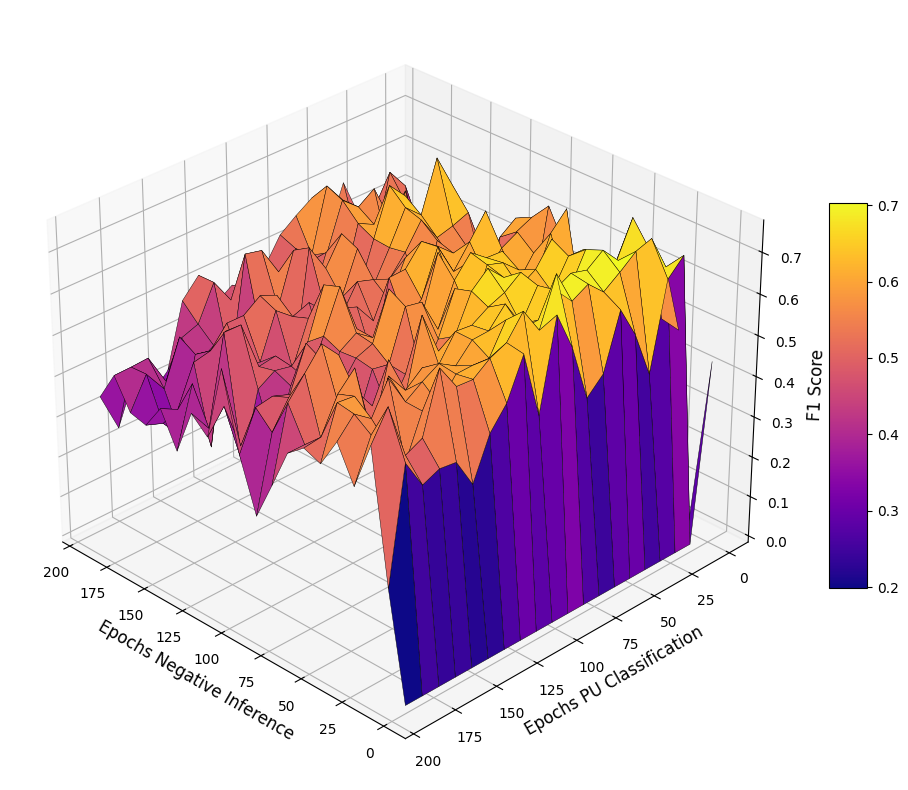

In [224]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

# Carregar e agregar os dados
df = pd.read_csv('results/epochs_results_Cora.csv')
df = df[df['model'] == 'RGCN']
df_avg = df.groupby(['epochs_pu', 'epochs_neginf'], as_index=False)['f1'].mean()
pivot = df_avg.pivot(index='epochs_pu', columns='epochs_neginf', values='f1')

# Preparar malha
ep1 = pivot.columns.to_numpy()
ep2 = pivot.index.to_numpy()
Ep1, Ep2 = np.meshgrid(ep1, ep2)
F1 = pivot.to_numpy()

# Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Escolher um colormap mais vibrante
surf = ax.plot_surface(Ep1, Ep2, F1, cmap='plasma', edgecolor='k', linewidth=0.3, antialiased=True)

# Ajuste dos rótulos
ax.set_xlabel('Epochs Negative Inference', fontsize=12)
ax.set_ylabel('Epochs PU Classification', fontsize=12)
ax.set_zlabel('F1 Score', fontsize=12)
# plt.title('F1 Score por Épocas dos Modelos', fontsize=14)

# Barra de cores para indicar escala
fig.colorbar(surf, shrink=0.5, aspect=10)

# Ajuste da visão (ângulo de inclinação e rotação)
ax.view_init(elev=30, azim=135)

plt.tight_layout()
plt.savefig(f'plots/epochs_cora_rgcn.svg', format='svg')
# plt.plot()
plt.show()


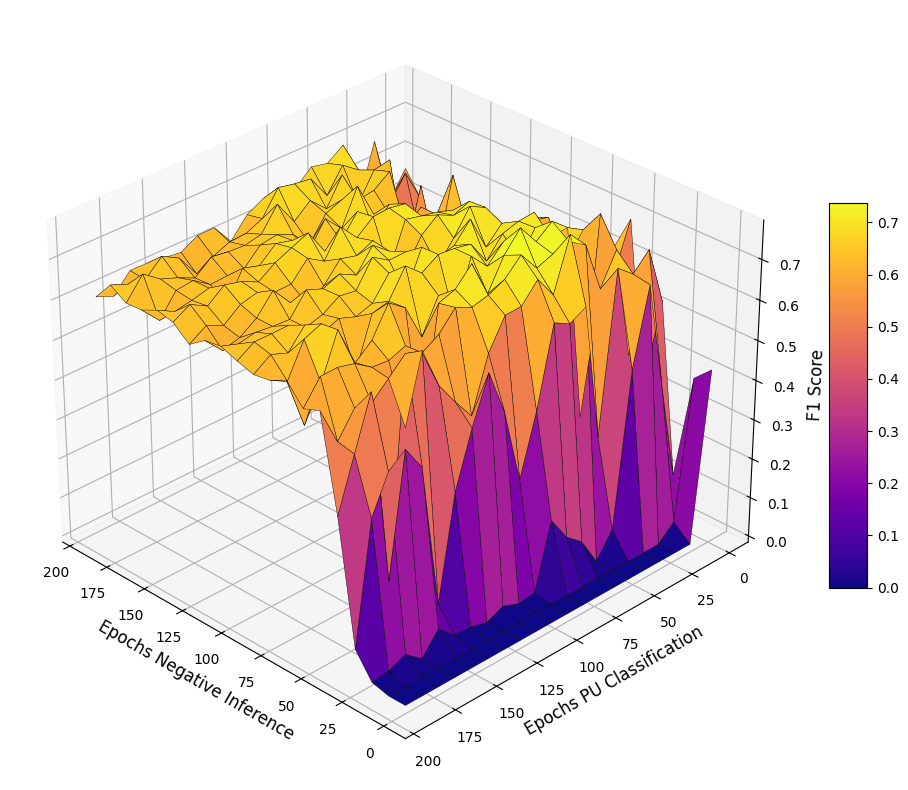

In [225]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

# Carregar e agregar os dados
df = pd.read_csv('results/epochs_results_Cora.csv')
df = df[df['model'] == 'GCN']
df_avg = df.groupby(['epochs_pu', 'epochs_neginf'], as_index=False)['f1'].mean()
# df_avg = df_avg[df_avg['f1'] > 0.1]
pivot = df_avg.pivot(index='epochs_pu', columns='epochs_neginf', values='f1')

# Preparar malha
ep1 = pivot.columns.to_numpy()
ep2 = pivot.index.to_numpy()
Ep1, Ep2 = np.meshgrid(ep1, ep2)
F1 = pivot.to_numpy()

# Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Escolher um colormap mais vibrante
surf = ax.plot_surface(Ep1, Ep2, F1, cmap='plasma', edgecolor='k', linewidth=0.3, antialiased=True)

# Ajuste dos rótulos
ax.set_xlabel('Epochs Negative Inference', fontsize=12)
ax.set_ylabel('Epochs PU Classification', fontsize=12)
ax.set_zlabel('F1 Score', fontsize=12)
# plt.title('F1 Score por Épocas dos Modelos', fontsize=14)

# Barra de cores para indicar escala
fig.colorbar(surf, shrink=0.5, aspect=10)

# Ajuste da visão (ângulo de inclinação e rotação)
ax.view_init(elev=30, azim=135)

plt.tight_layout()
plt.savefig(f'plots/epochs_cora_gcn.svg', format='svg')
# plt.plot()
plt.show()
